# Homework 0 - Using k-NN to Analyze Scientific Data

This assignment will be using the elementary KNN classification model to classify data from the penguin dataset. This assignment will focus on performing operations and manipulations on the data to get clear insight.

In [219]:
# Adding all dependencies to the environment
import pandas as pd  # Data manipulation and analysis
import scipy as sc  # Scientific Computing
import numpy as np  # Numerical Computing
import matplotlib.pyplot as plt  # Data Visualization with Static Plots
import plotly.graph_objects as go  # Interative Data Visualization
import math  # Standard Library for Math Operations
from sklearn.model_selection import train_test_split  # Data Splitting
from sklearn.neighbors import KNeighborsClassifier  # ML Models
from sklearn.base import BaseEstimator  # Generalized Model Type-Checking
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report  # Evaluating Model Performance

## Problem 1 - Loading the dataset

Loading the penguins dataset (*peguins_size*) into a dataframe.

In [220]:
df = pd.read_csv('data/penguins_size.csv')  # Load the csv file into a pandas dataframe

## Problem 2 - Cleaning the data

Firstly, examining the dataframe.

In [221]:
print(f"Columns:\n{df.dtypes}\n")
print(f"Description:\n{df.describe}")

Columns:
species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Description:
<bound method NDFrame.describe of     species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen              39.1             18.7              181.0   
1    Adelie  Torgersen              39.5             17.4              186.0   
2    Adelie  Torgersen              40.3             18.0              195.0   
3    Adelie  Torgersen               NaN              NaN                NaN   
4    Adelie  Torgersen              36.7             19.3              193.0   
..      ...        ...               ...              ...                ...   
339  Gentoo     Biscoe               NaN              NaN                NaN   
340  Gentoo     Biscoe              46.8             14.3              215.0   
341  G

Removing any incomplete records.

In [222]:
df = df.dropna(how="any")  # Dropping any incomplete data
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


Verifying that the new dataframe only contains complete records.

In [223]:
print(df.isna().sum())  # Obtain a count of rows that contain an incomplete record

df  # Display the full dataframe

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


## Problem 3 - Integer classifications for columns

Create integer categorizations for the original species and sex fields, named species_type and sex_type.

First, determine the unique names for species and sex.

In [224]:
# Obtain the unique names for species and sex
species_names = df['species'].unique()
sex_names = df['sex'].unique()
print(f"Species Names: {species_names}, Sex Names: {sex_names}")  # Quick manual verification

Species Names: ['Adelie' 'Chinstrap' 'Gentoo'], Sex Names: ['MALE' 'FEMALE' '.']


Next, categorize these names into integer representations, add to the df, and convert from floats to ints.

In [225]:

# Create new df columns for species types and sex types
for i in range(len(species_names)):
    df.loc[df['species'] == species_names[i], 'species_type'] = i
for j in range(len(sex_names)):
    df.loc[df['sex'] == sex_names[j], 'sex_type'] = j
    
# Converting the float columns to ints
df = df.astype({'species_type': 'int32', 'sex_type': 'int32'})
    
# Verify the new df with a random sample
df.sample(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,species_type,sex_type
266,Gentoo,Biscoe,45.5,13.9,210.0,4200.0,FEMALE,2,1
136,Adelie,Dream,35.6,17.5,191.0,3175.0,FEMALE,0,1
74,Adelie,Torgersen,35.5,17.5,190.0,3700.0,FEMALE,0,1
201,Chinstrap,Dream,49.8,17.3,198.0,3675.0,FEMALE,1,1
148,Adelie,Dream,36.0,17.8,195.0,3450.0,FEMALE,0,1
245,Gentoo,Biscoe,46.1,15.1,215.0,5100.0,MALE,2,0
303,Gentoo,Biscoe,50.0,15.9,224.0,5350.0,MALE,2,0
125,Adelie,Torgersen,40.6,19.0,199.0,4000.0,MALE,0,0
186,Chinstrap,Dream,49.7,18.6,195.0,3600.0,MALE,1,0
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE,2,1


## Problem 4 - Feature Selection

First, we should do an initial selection of which features could be used to obtain the best accuracy. 

Using simple domain knowledge, we know that attributes that define geographical or physical features would be beneficial, while attributes such as sex or indexes may not. Therefore, we can start with these attributes.

In [226]:
# Map the island names to integers
island_names = df['island'].unique()
for i in range(len(island_names)):
    df.loc[df['island'] == island_names[i], 'island_type'] = i
df = df.astype({'island_type': 'int32'})  # Convert to int32

# Create a list of possible features to consider
possible_features = ['island_type', 'culmen_length_mm', 'culmen_depth_mm', \
                       'flipper_length_mm', 'body_mass_g']

Now that we have the deisred features, we isolate the features and target.

In [227]:
y_df = df['species_type']  # Target
x_df = df[possible_features]  # Features

Split the data into training and testing sets

In [228]:
# Split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_df, y_df, test_size=.25, random_state=42)

To optimize the features used, we can define a function that intakes a model and iteratively tries different feature sets.

In [229]:
import itertools
# Helper function for testing the model, given a set of features
def test_model_accuracy(model_cls: BaseEstimator, df: pd.DataFrame, c: list[str], target_df: pd.DataFrame, **model_kwargs) -> tuple[float, BaseEstimator]:
    '''
    Helper function to assess a given model using given feature set and target dataframe
    Returns the accuracy and model
    '''
    # Because of bad naming and whatnot, convert combinations to actual dataframe
    temp_feature_df: pd.DataFrame = df[c]  # Get the dataframe of just selected features, cast to list of strings
    y = target_df.squeeze()
    # Split into testing and training
    x_train, x_test, y_train, y_test = train_test_split(temp_feature_df, y, test_size=.25, random_state=42, stratify=y)
    # Fit the data to the model and evaluate
    model = model_cls(**model_kwargs)  # Initialize the model with given parameters
    model.fit(x_train, y_train)
    return model.score(x_test, y_test), model  # Return the model accuracy and the trained model

# Main function to test all features to find the best set
def test_features(features: list, df: pd.DataFrame, target_df: pd.DataFrame, model_cls: BaseEstimator = KNeighborsClassifier, **model_kwargs) -> BaseEstimator:
    ''' 
    Helper function to iteratively check all set of features, 
    printing the best set of features and returning the best model
    NOTE: This could be computational expensive and not optimal for large models/feature sets
    '''
    best_accuracy: float = 0  # Tracker for the best accuracy
    best_model: BaseEstimator = None  # Tracker for the best model
    best_feature_set: list[str] = [] # Tracker for the best feature set
    
    # Iterate through all possible feature combinations, testing each
    for i in range(len(features)):
        if i == 0: continue  # Skip the empty set
        combinations = itertools.combinations(features, i)  # Get all combinations of size i
        for c in combinations:
            c = list(map(str, c))
            # Test the accuracy with the new feature set, and update accordingly
            accuracy, cur_model = test_model_accuracy(model_cls=model_cls, df=df, c=c, target_df=target_df, **model_kwargs)
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_model = cur_model
                best_feature_set = c
    
    # Print the best accuracy and return the optimal model
    print(f"The best accuracy was {best_accuracy} with the feature set of {best_feature_set}")
    return best_model

## Problem 5 - Understanding the Training Data

Generating descriptive statistics for the training dataset.

In [230]:
x_train.describe()  # Obtaining descriptive statistics of the feature training data

,island_type,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,250.000000,250.000000,250.000000,250.00000,250.000000
mean,1.260000,44.224000,17.132400,201.18800,4212.400000
std,0.664958,5.341606,1.972713,13.87352,810.090257
min,0.000000,32.100000,13.200000,172.00000,2700.000000
25%,1.000000,39.625000,15.500000,190.00000,3550.000000
50%,1.000000,45.200000,17.300000,197.00000,4050.000000
75%,2.000000,48.700000,18.700000,213.00000,4800.000000
max,2.000000,59.600000,21.500000,231.00000,6300.000000


Generating a scatter matrix visualization for the training dataset.

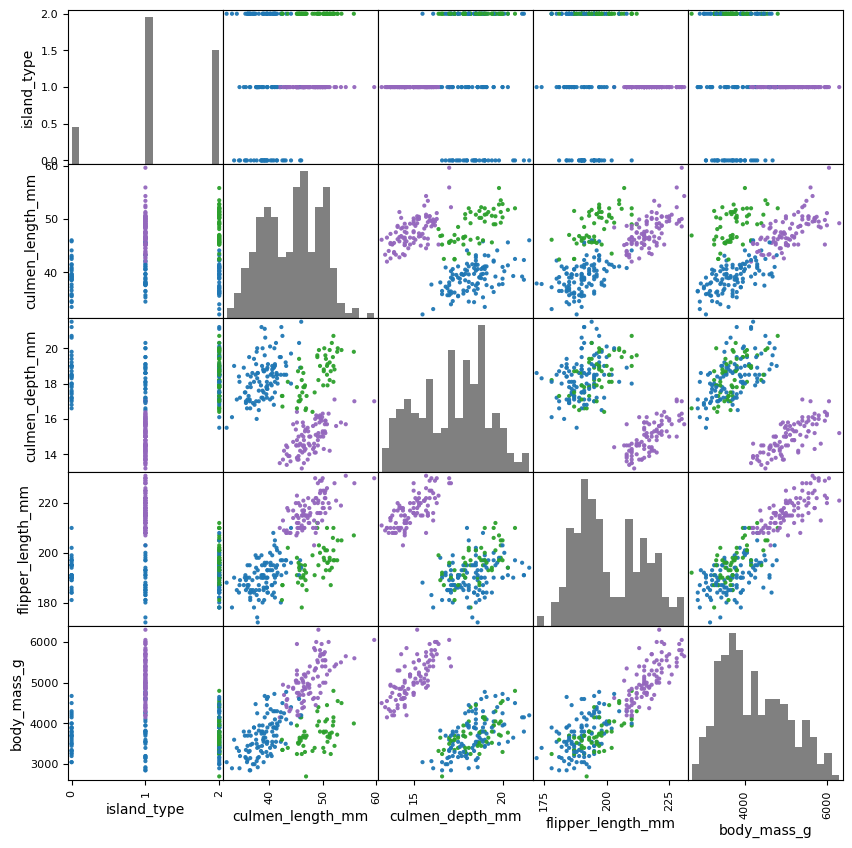

In [231]:
# Creating a tailored colormap
import matplotlib.colors as mplcolors
custom_color_map = mplcolors.ListedColormap(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])

# Create a scatter matrix from the dataframe
colormapScatterMatrix = pd.plotting.scatter_matrix(
                                                    frame=x_train,  # Data to map
                                                    alpha=.95,  # Transparency applied
                                                    hist_kwds={'bins': 20, 'color': 'gray'}, # Keywords to be used in the histograms
                                                    c=y_train,  # Overlapping Data (target)
                                                    cmap=custom_color_map,  # Color map
                                                    figsize=(10,10),  # Figure size, large to fit all text
                                                )

## Problem 6 - Creating a k-NN Classifier Model

First, training a SKLearn k-NN classifier model.

In [232]:
N_NEIGHBORS: int = 5  # Number of neighbords for our model, may be adjusted
knn_model = KNeighborsClassifier(
                                  n_neighbors=N_NEIGHBORS,  # Number of neighbors
                                  n_jobs=-1,  # Use all processors for the model
                               )  # All other parameters are set to default values

knn_model.fit(X=x_train, y=y_train)  # Training the model on the training data

KNeighborsClassifier(n_jobs=-1)

Then, we can test our classification model using the x_test and y_test data.

In [233]:
# Getting our results from the model
results = knn_model.predict(x_test)

# Print the mean accuracy of the model
print(f"Mean Accuracy: {knn_model.score(x_test, y_test)}")

# Print the k-neighbors graph, because we can
kneighbors_graph_results = knn_model.kneighbors_graph(x_test)
kneighbors_graph_results.toarray()

Mean Accuracy: 0.8333333333333334


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.]])

Now, we can use the methods defined above to determine the best feature set.

In [234]:
optimal_model_test = test_features(
                                    features=possible_features,  # All possible features
                                    df=df,
                                    target_df=y_df,
                                    model_cls=KNeighborsClassifier,  # Model class
                                    n_neighbors=N_NEIGHBORS  # Any model parameters as kwargs
                                  )

The best accuracy was 0.9880952380952381 with the feature set of ['island_type', 'culmen_length_mm', 'culmen_depth_mm']


In [235]:
# Using the optimal feature set found previously to re-create the model and splits
optimal_feature_set = ['island_type', 'culmen_length_mm', 'culmen_depth_mm']
x_train_optimal, x_test_optimal, y_train_optimal, y_test_optimal = \
    train_test_split(
                        df[optimal_feature_set],  # New x-df
                        y_df.squeeze(),  # Target (species-type, 1d)
                        test_size=.25,
                        random_state=42,
                        stratify=y_df  # Ensuring balanced classes in splits
                        
                    )
optimal_model = KNeighborsClassifier(n_neighbors=N_NEIGHBORS, n_jobs=-1).fit(x_train_optimal, y_train_optimal)

optimal_model

KNeighborsClassifier(n_jobs=-1)

# Problem 7 - Describing the Results

To numerically describe the results, we can use the following metrics:

- Accuracy Score
- Confusion Matrix
- Precision/Recall/F1 Scores (Classification Reports)

### Accuracy

In [236]:
optimal_model.score(x_test_optimal, y_test_optimal)

0.9880952380952381

This accuracy of **98.81%** tells us that this is a high-performing model, correctly predicting the test data (containing a 25% split of the total data) over 98% of the time. In this context (assuming that the collected data is correct), a researcher could reliably predict a penguin species based on the 'island_type', 'culmen_length_mm', and 'culmen_depth_mm'.

### Confusion Matrix

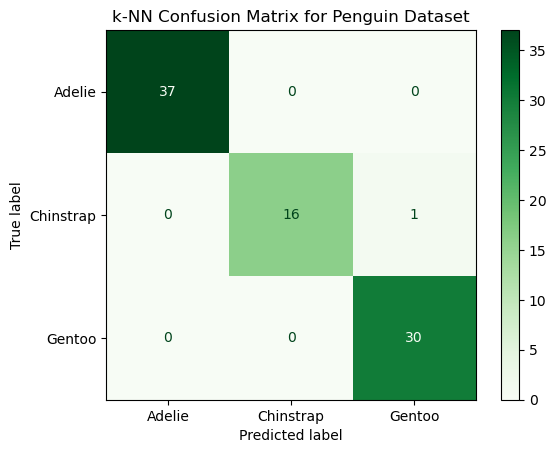

In [237]:
CM_TITLE: str = "k-NN Confusion Matrix for Penguin Dataset"  # Explicitly stating title

# Plotting a non-normalized confusion Matrix
disp = ConfusionMatrixDisplay.from_estimator(
    optimal_model,  # Model to graph
    x_test_optimal,
    y_test_optimal,
    cmap=plt.cm.Greens,  # Use a green colorscheme
    display_labels=species_names  # Map integers to species names, as declared earlier
)
disp.ax_.set_title(CM_TITLE)
plt.show()

This confusion matrix informs us of *where* the model accurately classified a species. In this context, a researcher would know that the model is **most likely to misclassify** a *Chinstrap* as a *Gentoo*, with this misclassification occuring roughly 6% of the time. However, we can predict that the model will accurately predict the *Adelie* and *Gentoo* species in nearly every instance.

### Classification Report

In [238]:
y_pred_optimal = optimal_model.predict(x_test_optimal)  # Obtaining the actual predictions

# Generating a classification report to gather advanced metrics
print(classification_report(
                              y_test_optimal,  # Ground truth  
                              y_pred_optimal,  # Predicted classifications
                              target_names=species_names  # Mapping names to actual species names, rather than ints
                            ))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        37
   Chinstrap       1.00      0.94      0.97        17
      Gentoo       0.97      1.00      0.98        30

    accuracy                           0.99        84
   macro avg       0.99      0.98      0.98        84
weighted avg       0.99      0.99      0.99        84



Similarly to the confusion matrix, this classification report helps us gauge the model's performance and where it most commonly underperforms. 

Firstly, the ***precision*** displays the accuracy of positive predictions, showing how many positive classifications were actually positive. In this context, a researcher could assume that all positives generated by the model for the *Adelie* and *Chinstrap* species are correct, with positive classifications of *Gentoo*s being incorrect about 3% of the time. However, looking at the overall weighted average of 99% precision, the researcher could confidently assume that nearly all positives generated by the model are correct.

Next, the ***recall*** measures the model's ability to find all positive instances, showing how many of the actual positives the model correctly identified. In this context, the researcher could assume that nearly all *Adelie*'s and *Gentoo*'s will be correctly identified. *Chinstrap*'s are only correctly found approximately 96% of the time, showing the model may sometimes miss instances of this species. However, looking at the overall weighted recall of 99%, the researcher could confidently assume that the model will indentify nearly all positives.

Lastly, the ***f1-score*** serves as a mix between precision and recall, placing both metrics into a single number. This number would likely be most interpretable for a researcher, as it accounts for precision-recall tradeoffs. Firstly, the f1-score for the *Adelie* species is 1.00, showcasing that this species will almost always be correctly identified. The *Chinstrap* and *Gentoo* species have high f1-scores of .97 and .98, respectively, which indicates very high but not perfect 'accuracy'. This could caution the researcher to practice some caution when using the model to identify these species, however these predictions are still relatively strong.

## Problem 8 - Testing Different $k$ Values

In a k-NN model, $k$ refers to the number of neighbors considered when making a prediction. In order to potentially optimize our model and see the behavior of $k$, we can test various $k$ values.

In [239]:
MIN_K: int = 1  # Setting minimum k bound
MAX_K: int = 10  # Setting maximum k bound
BEST_ACCURACY: float = float(0)  # Initializing the best accuracy for tracking purposes
BEST_K: int = 0  # Initializing the best k value with signal

def eval_k_knn(k: int) -> float:
    '''
    Helper function to test a given k value in a k-NN model, returning the accuracy 
    '''
    cur_model: KNeighborsClassifier = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)  # Creating the new model
    cur_model.fit(x_train_optimal, y_train_optimal)  # Fit with correct X and y
    return cur_model.score(x_test_optimal, y_test_optimal)
 
''' Loop through each k value in the bound, printing each accuracy and tracking the best '''
for k in range(MIN_K, MAX_K, 1):
    cur_accuracy = eval_k_knn(k)  # Call the helper function to get the accuracy
    print(f"Accuracy for k={k}: {cur_accuracy}")
    if cur_accuracy > BEST_ACCURACY:
        BEST_ACCURACY = cur_accuracy
        BEST_K = k
        
print(f"Best-performing k value={BEST_K} with an accuracy of {BEST_ACCURACY}")

Accuracy for k=1: 0.9880952380952381
Accuracy for k=2: 1.0
Accuracy for k=3: 0.9880952380952381
Accuracy for k=4: 0.9880952380952381
Accuracy for k=5: 0.9880952380952381
Accuracy for k=6: 0.9880952380952381
Accuracy for k=7: 0.9880952380952381
Accuracy for k=8: 0.9880952380952381
Accuracy for k=9: 0.9880952380952381
Best-performing k value=2 with an accuracy of 1.0


Under the hood, the $k$ value determines the amount of *neighboring* data points to observe when classifying. When running these tests, we see that **$k$=2** warrants the best results, having an accuracy of **1.0** (100%). This means that, when this model looks at only the closest two neighbors, it always correctly predicts the testing class.

## Problem 9 - Optimizing the k-NN Classifier

As previously seen, this k-NN classifying model can be optimized by setting $k$ to 2:
```{py}
optimal_model = KNeighborsClassifier(n_neighbors=BEST_K, n_jobs=-1).fit(x_train_optimal, y_train_optimal)
```

This would warrant all **perfect metrics** *(accuracy, precision, recall, f1-score)*, obtaining a perfect model. Although this is achievable with this dataset, this type of accuracy will almost never be seen for real-data. To optimize a classifier such as k-NN, parameter tuning (potentially more than just $k$ values) with methods such as *GridSearchCV* would ensure the best model for a given dataset. 

## References (Problem 10)

- [Pandas Online Documentation - Missing Data](https://pandas.pydata.org/docs/user_guide/10min.html#missing-data)
- [Pandas Online Documentation - Where Method](https://pandas.pydata.org/docs/user_guide/indexing.html#the-where-method-and-masking)
- [Pandas Online Documentation - Scatter Matrix](https://pandas.pydata.org/docs/reference/api/pandas.plotting.scatter_matrix.html)
- [Scikit-learn Documentation (Base Estimator for Typing, KNN, ConfusionMatrixDisplay, & Classification Report)](https://scikit-learn.org/stable/index.html)